<a href="https://colab.research.google.com/github/Edenshmuel/CrimeData/blob/main/XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import zipfile
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
import pandas as pd
import requests
from io import BytesIO

Loading Supervised Datasets from GitHub Repository

In [2]:
# Define the ZIP file URL
zip_url = "https://github.com/Edenshmuel/CrimeData/raw/main/supervised_dataset.zip"

# Function to load a specific CSV file from the ZIP in GitHub
def load_csv_from_zip(zip_url, inner_file_name):
    response = requests.get(zip_url)
    if response.status_code == 200:
        with zipfile.ZipFile(BytesIO(response.content)) as z:
            with z.open(inner_file_name) as f:
                return pd.read_csv(f)
    else:
        raise Exception("Failed to download supervised_dataset.zip")

# Load datasets from the ZIP
X_train = load_csv_from_zip(zip_url, "X_train_supervised.csv")
X_test = load_csv_from_zip(zip_url, "X_test_supervised.csv")
y_train = load_csv_from_zip(zip_url, "y_train_supervised.csv").values.ravel()
y_test = load_csv_from_zip(zip_url, "y_test_supervised.csv").values.ravel()

In [3]:
# Remove the feature indicating missing StatisticArea
X_train = X_train.drop(columns=["is_missing_StatisticArea"])
X_test = X_test.drop(columns=["is_missing_StatisticArea"])

print("New training shape:", X_train.shape)
print("New test shape:", X_test.shape)

New training shape: (1362116, 14)
New test shape: (404811, 14)


Defining the XGBoost Classifier with Hyperparameters

In [4]:
# Initialize the XGBoost model with specified hyperparameters
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    random_state=42)

Training the XGBoost Classifier

In [5]:
# Train the XGBoost model using the training data
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

Making Predictions with the Trained XGBoost Classifier

In [6]:
# Generate predictions on the test set using the trained XGBoost model
y_pred = xgb_model.predict(X_test)

Evaluation Function for Classification Models

In [7]:
# Define a function to evaluate a classification model using multiple metrics
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

Printing the Performance of the XGBoost Model

In [8]:
# Evaluate the XGBoost model using the custom evaluation function
xgb_metrics = evaluate_model(y_test, y_pred)

print("Improved XGBoost Metrics:", xgb_metrics)

Improved XGBoost Metrics: {'Accuracy': 0.3920718557549078, 'Precision': 0.34291559252681153, 'Recall': 0.3920718557549078, 'F1 Score': 0.3178892729561722}


Feature Importance Analysis

Feature importance:
                      Feature  Importance
12        StationsNearbyCount    0.260514
2              PoliceDistrict    0.202348
10        StationCrimeRateAvg    0.091459
3                PoliceMerhav    0.087925
13        CityOrMoshav_Moshav    0.075284
7             YeshuvCrimeRate    0.070505
4               PoliceStation    0.056368
5               StatisticArea    0.042349
1                      Yeshuv    0.037032
0                        Year    0.034672
9        CrimeTrend_CrimeRate    0.017966
8                  CrimeTrend    0.011919
6             Quarter_numeric    0.011659
11  YeshuvHistoricalCrimeRate    0.000000


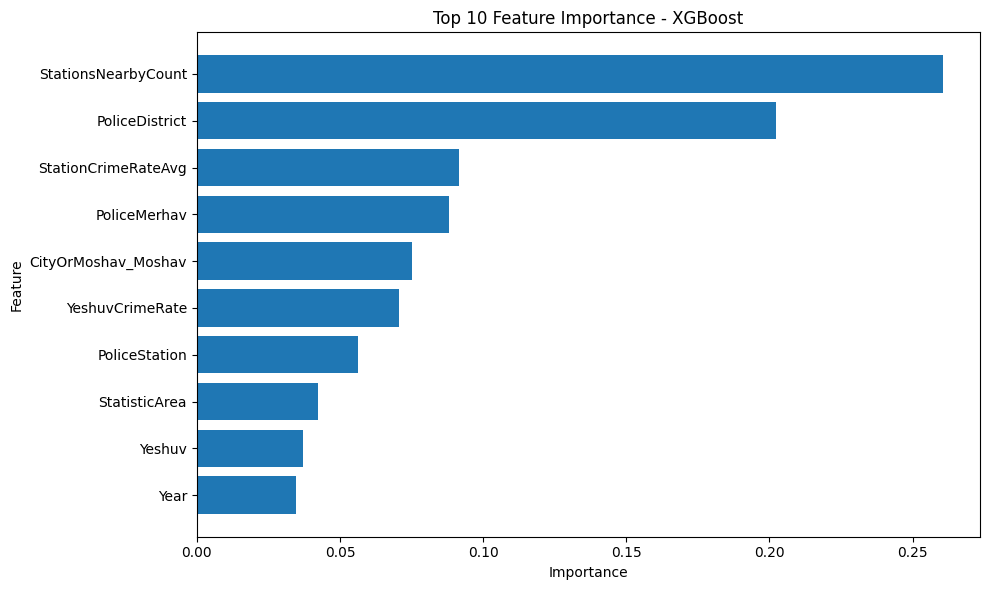

In [12]:
# Create a DataFrame with feature names and importance scores
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Print the full table
print("Feature importance:")
print(feature_importance_df)

# Plot the top 10 most important features
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance results indicate that crime group prediction is driven mainly by geographic and spatial variables rather than temporal ones. This suggests that different crime groups are more strongly associated with specific locations and local crime environments than with changes over time.

SHAP Analysis for a Dominant Crime Group

In [13]:
# Install SHAP if needed
!pip install shap -q

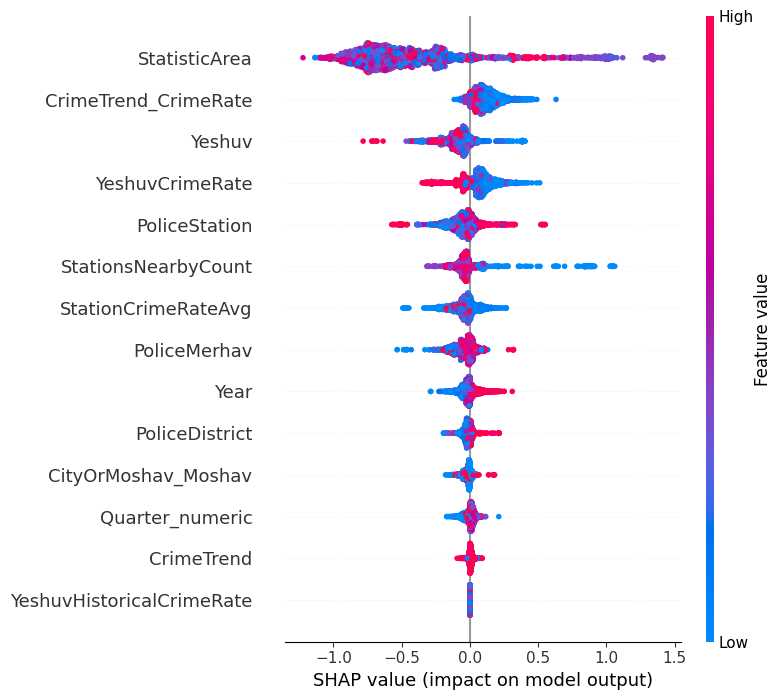

In [14]:
# SHAP Analysis for a Dominant Crime Group

import shap

# Select a target class to analyze
target_class = 4

# Take a sample from the test set to make SHAP faster
X_sample = X_test.sample(n=min(3000, len(X_test)), random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# If this is a multiclass model, select the SHAP values of the target class
if isinstance(shap_values, list):
    shap_values_class = shap_values[target_class]
else:
    shap_values_class = shap_values[:, :, target_class]

# Summary plot for the selected class
shap.summary_plot(shap_values_class, X_sample)

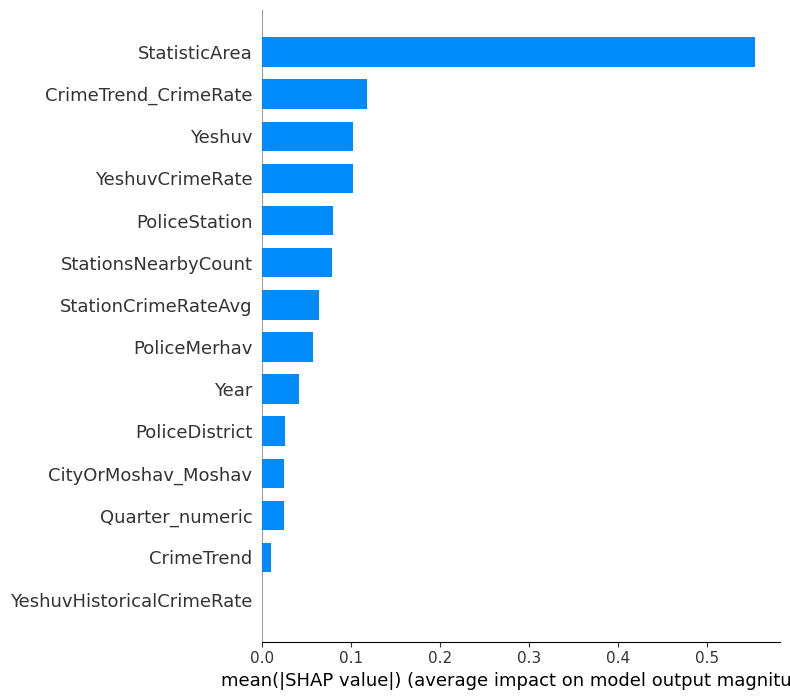

In [16]:
# SHAP bar plot for the selected class

shap.summary_plot(shap_values_class, X_sample, plot_type="bar")